# Fertilizer recommendation
Fertilozz is an AI-powered application that helps farmers anticipate crops and increase productivity. In addition to offering suitable fertilisation recommendations for your fields, we also provide sales forecasts for the specific crop based on supply and demand. We also provide suitable guidance on the tools that they should utilise, as well as a purchase link. Ultimately, we serve as a useful tool for farmers.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data analysis

In [ ]:
df = pd.read_csv("Soil_type.csv")
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [4]:
df.shape

(2200, 8)

In [5]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
df['label'].value_counts()

rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: label, dtype: int64

# Outlier removal and normalization

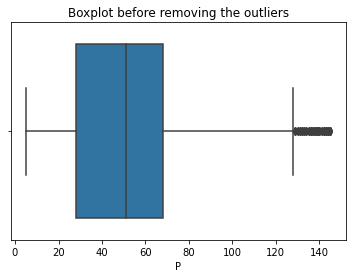

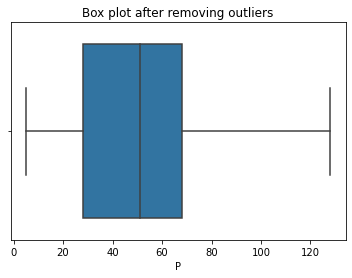

In [ ]:
sns.boxplot(df['P'])
plt.title('Boxplot before removing the outliers')
plt.show()

def replace_outliers(df, field_name):
    Q1 = np.percentile(df[field_name],25,interpolation='midpoint')
    Q3 = np.percentile(df[field_name],75,interpolation='midpoint')
    IQR = Q3-Q1
    maxi = Q3+1.5*IQR
    mini = Q1-1.5*IQR
    df[field_name]=df[field_name].mask(df[field_name]>maxi,maxi)
    df[field_name]=df[field_name].mask(df[field_name]<mini,mini)

replace_outliers(df, 'P')
sns.boxplot(df['P'])
plt.title('Box plot after removing outliers')
plt.show()

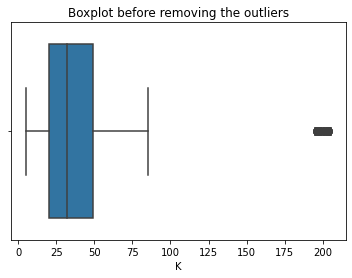

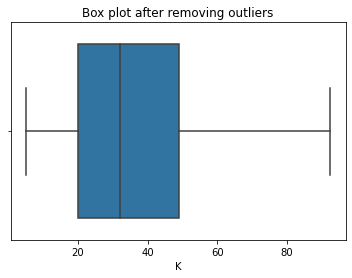

In [8]:
sns.boxplot(df['K'])
plt.title('Boxplot before removing the outliers')
plt.show()

replace_outliers(df, 'K')
sns.boxplot(df['K'])
plt.title('Box plot after removing outliers')
plt.show()

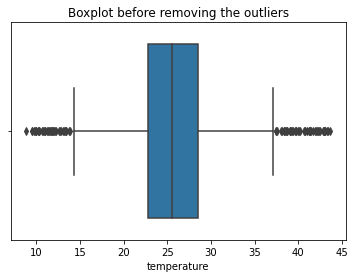

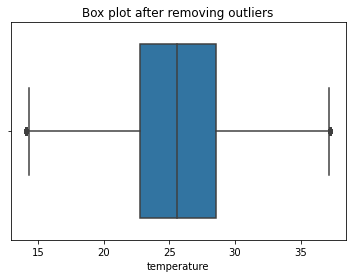

In [9]:
sns.boxplot(df['temperature'])
plt.title('Boxplot before removing the outliers')
plt.show()

replace_outliers(df, 'temperature')
sns.boxplot(df['temperature'])
plt.title('Box plot after removing outliers')
plt.show()

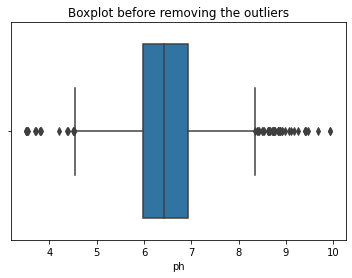

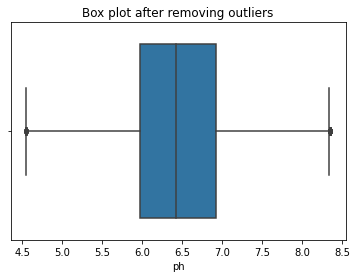

In [10]:
sns.boxplot(df['ph'])
plt.title('Boxplot before removing the outliers')
plt.show()

replace_outliers(df, 'ph')
sns.boxplot(df['ph'])
plt.title('Box plot after removing outliers')
plt.show()

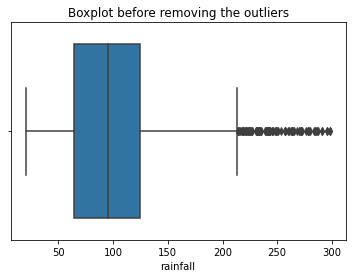

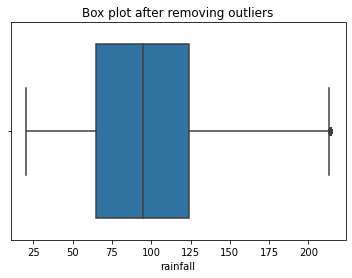

In [11]:
sns.boxplot(df['rainfall'])
plt.title('Boxplot before removing the outliers')
plt.show()

replace_outliers(df, 'rainfall')
sns.boxplot(df['rainfall'])
plt.title('Box plot after removing outliers')
plt.show()

In [12]:
df['label'] = df['label'].replace({"rice":0,"maize":1, 'jute':2, 'cotton':3, 'coconut':4, 'papaya':5, 'orange':6, 'apple':7, 
                                   'muskmelon':8, 'watermelon':9,'grapes':10, 'mango':11,  'banana':12, 'pomegranate':13,  
                                   'lentil':14, 'blackgram':15,'mungbean':16, 'mothbeans':17, 'pigeonpeas':18,'kidneybeans':19, 
                                   'chickpea':20, 'coffee':21})

In [13]:
df['label'].value_counts()

0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
Name: label, dtype: int64

# Data Modelling

In [14]:
Data = df.drop('label',axis=1)
Y = df['label']

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(Data,Y,test_size=0.25,random_state=42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1650, 7)
(550, 7)
(1650,)
(550,)


# Model Building

In [17]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [18]:
x_pred = nb.predict(X_train)
y_pred = nb.predict(X_test)

In [19]:
from sklearn.metrics import plot_confusion_matrix,accuracy_score,classification_report
print("Training accuracy on standardized data:",accuracy_score(y_train,x_pred))
print("Testing accuracy on standardized data:",accuracy_score(y_test,y_pred))

Training accuracy on standardized data: 0.9963636363636363
Testing accuracy on standardized data: 0.9927272727272727


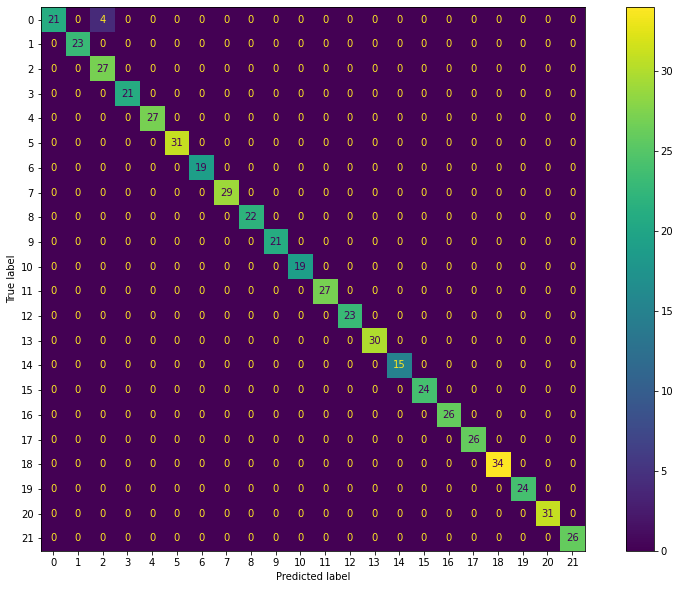

In [20]:
fig,ax = plt.subplots(figsize=(15,10))
plot_confusion_matrix(nb,X_test,y_test,values_format='d',ax=ax)

In [21]:
cr1 = classification_report(y_test,y_pred)
print(cr1)

              precision    recall  f1-score   support

           0       1.00      0.84      0.91        25
           1       1.00      1.00      1.00        23
           2       0.87      1.00      0.93        27
           3       1.00      1.00      1.00        21
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        31
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        29
           8       1.00      1.00      1.00        22
           9       1.00      1.00      1.00        21
          10       1.00      1.00      1.00        19
          11       1.00      1.00      1.00        27
          12       1.00      1.00      1.00        23
          13       1.00      1.00      1.00        30
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        24
          16       1.00      1.00      1.00        26
          17       1.00    

In [22]:
from sklearn.metrics import roc_curve
pred_prob1 = nb.predict_proba(X_test)
fpr1,tpr1,thresh1 = roc_curve(y_test,pred_prob1[:,1],pos_label=1)

In [23]:
random_prob = [0 for i in range(len(y_test))]
p_fpr , p_tpr , _ = roc_curve(y_test,random_prob, pos_label=1)

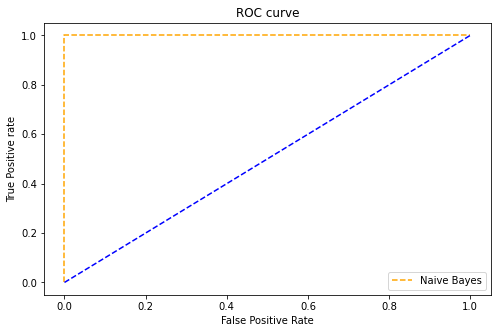

In [24]:
plt.figure(figsize=(8,5))
plt.plot(fpr1, tpr1, linestyle='--',color='orange', label='Naive Bayes')
plt.plot(p_fpr, p_tpr, linestyle='--', color='blue')
plt.title('ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='best')

# Accuracy for all ML models

In [25]:
from lazypredict.Supervised import LazyClassifier
clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:05<00:00,  5.79it/s]


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
GaussianNB,0.99,0.99,None,0.99,0.03
RandomForestClassifier,0.99,0.99,None,0.99,0.42
QuadraticDiscriminantAnalysis,0.99,0.99,None,0.99,0.03
BaggingClassifier,0.99,0.99,None,0.99,0.09
ExtraTreesClassifier,0.98,0.98,None,0.98,0.30
DecisionTreeClassifier,0.98,0.98,None,0.98,0.04
XGBClassifier,0.98,0.98,None,0.98,0.66
LGBMClassifier,0.98,0.98,None,0.98,0.85
SVC,0.97,0.97,None,0.97,0.17


# Model saving and testing

In [26]:
from pickle import dump,load
fertilizer = 'fert.pkl'
dump(nb,open(fertilizer,'wb'))

In [27]:
label = ["rice","maize", 'jute', 'cotton', 'coconut', 'Papaya', 'orange', 'apple', 'muskmelon', 'watermelon',   
'grapes', 'mango',  'banana', 'pomegranate',  'lentil', 'blackgram','mungbean', 'mothbeans',      
'pigeonpeas','kidneybeans', 'chickpea', 'coffee']

In [28]:
model = load(open(fertilizer,'rb'))
value = [27,62,24,28.63,66.77,7.35,62.27]
pred = model.predict([value])
print("Predicted Crop:",label[pred[0]])

Predicted Crop: blackgram


# Conclusion

* We use GaussianNB for model building.
* GaussianNB works well for multi class configuration and gives better predcition on discrete continuous values.
* Model states an accuracy of 99% in both train and test data set.
* ROC have more true positives and very less false positive.